<a href="https://colab.research.google.com/github/Amogh-S-Acharya/ML2-AMOGH_S_ACHARYA-4NI23CI012/blob/main/ml2_2_decisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import sklearn.model_selection as model_selection
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/student.csv")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
df.head()

,id,name,age,gender,study_hours,attendance,marks,result
0,1,Aarav,18,Male,4.5,92,85,Pass
1,2,Ananya,19,Female,6.0,95,91,Pass
2,3,Rahul,18,Male,2.5,78,58,Pass
3,4,Priya,20,Female,1.5,65,42,Fail
4,5,Arjun,19,Male,5.0,88,76,Pass


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           20 non-null     int64  
 1   name         20 non-null     object 
 2   age          20 non-null     int64  
 3   gender       20 non-null     object 
 4   study_hours  20 non-null     float64
 5   attendance   20 non-null     int64  
 6   marks        20 non-null     int64  
 7   result       20 non-null     object 
dtypes: float64(1), int64(4), object(3)
memory usage: 1.4+ KB


In [ ]:
df.isnull().sum()

,0
id,0
name,0
age,0
gender,0
study_hours,0
attendance,0
marks,0
result,0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df.isnull().sum()

,0
id,0
name,0
age,0
gender,0
study_hours,0
attendance,0
marks,0
result,0


In [ ]:
x = df[['age','study_hours','attendance','marks']]
y = df['result']

In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
y

array([1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1])

In [ ]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
  )

In [ ]:
len(x_train), len(x_test)

(16, 4)

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_test, y_pred

(array([1, 0, 1, 1]), array([0, 0, 1, 1]))

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [ ]:
acc, prec, rec, f1

(0.75, 1.0, 0.6666666666666666, 0.8)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1, 0],
       [1, 2]])

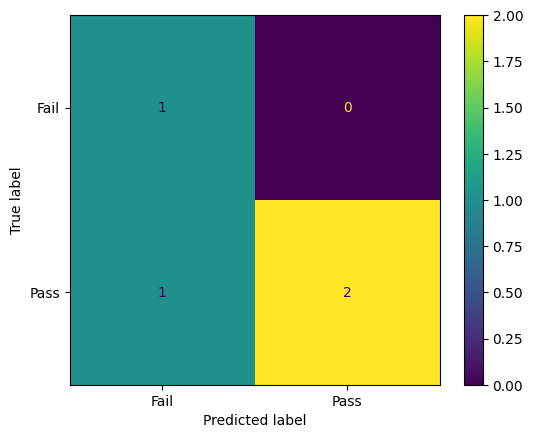

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)
disp.plot()
